## Lax--Friedrichs vs. Upwind

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maurimendiluce/AN2026/blob/main/diferencias_finitas/clase_6_hiperbolicas1.ipynb)


Comparamos numéricamente los dos esquemas para
$$
u_t + a u_x = 0, \qquad a>0,
$$
con condición inicial un pulso rectangular (discontinuo) y condiciones de contorno periódicas. La idea es ver "a ojo" lo que ya vimos en la teoría: ambos esquemas son disipativos, pero Lax--Friedrichs suaviza mucho más el frente del pulso que upwind, para el mismo número de Courant $\nu = a\Delta t/\Delta x$.

**Esquemas:**
$$
U_i^{n+1} = \frac12(U_{i+1}^n+U_{i-1}^n) - \frac{\nu}{2}(U_{i+1}^n-U_{i-1}^n) \qquad \text{(Lax--Friedrichs)}
$$
$$
U_i^{n+1} = U_i^n - \nu(U_i^n - U_{i-1}^n) \qquad \text{(Upwind, } a>0\text{)}
$$

In [1]:
using Plots

### Parámetros y condición inicial

In [7]:
a  = 1.0          # velocidad de advección
L  = 2.0          # largo del dominio (periódico)
N  = 200          # cantidad de nodos
dx = L / N
ν  = 0.99          # número de Courant, a*dt/dx
dt = ν * dx / a
T  = 1          # tiempo final
nsteps = round(Int, T / dt)

x = range(0, L, length=N+1)[1:end-1]   # malla periódica: x_N == x_0

# pulso rectangular en [0.2, 0.4]
u0 = Float64.((x .> 0.2) .& (x .< 0.4))

println("dx = $dx, dt = $dt, ν = $(a*dt/dx), nsteps = $nsteps")

dx = 0.01, dt = 0.0099, ν = 0.9900000000000001, nsteps = 101


### Los dos esquemas

Ambos con condiciones de contorno periódicas, implementadas con `circshift`.

In [3]:
function lax_friedrichs(u0, a, dx, dt, nsteps)
    u = copy(u0)
    ν = a * dt / dx
    for _ in 1:nsteps
        up = circshift(u, -1)   # U_{i+1}
        um = circshift(u,  1)   # U_{i-1}
        u  = 0.5 .* (up .+ um) .- 0.5 * ν .* (up .- um)
    end
    return u
end


function upwind(u0, a, dx, dt, nsteps)
    u = copy(u0)
    ν = a * dt / dx
    for _ in 1:nsteps
        um = circshift(u, 1)    # U_{i-1}
        u  = u .- ν .* (u .- um)
    end
    return u
end

upwind (generic function with 1 method)

### Solución exacta

La solución exacta es simplemente el pulso trasladado: $u(x,t) = u_0(x-at \mod L)$.

In [4]:
function exact(x, a, T, L)
    xs = mod.(x .- a*T, L)
    return Float64.((xs .> 0.2) .& (xs .< 0.4))
end

u_exact = exact(x, a, T, L)
u_lf    = lax_friedrichs(u0, a, dx, dt, nsteps)
u_uw    = upwind(u0, a, dx, dt, nsteps)

err_lf = sqrt(sum((u_lf .- u_exact).^2) / N)
err_uw = sqrt(sum((u_uw .- u_exact).^2) / N)
println("Error L2 Lax-Friedrichs: $err_lf")
println("Error L2 Upwind:         $err_uw")

Error L2 Lax-Friedrichs: 0.12959546425429017
Error L2 Upwind:         0.10199585465506032


### Comparación gráfica

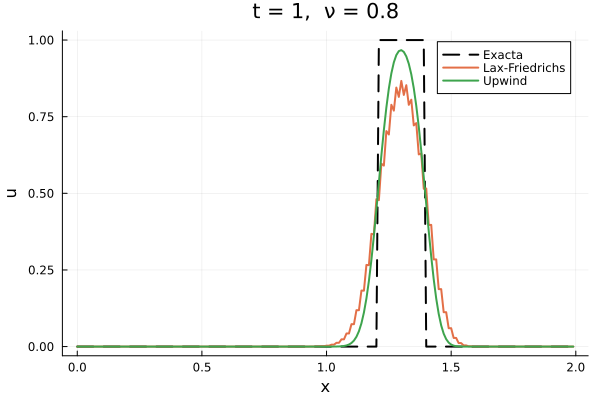

In [5]:
plot(x, u_exact, label="Exacta", lw=2, color=:black, linestyle=:dash)
plot!(x, u_lf, label="Lax-Friedrichs", lw=2)
plot!(x, u_uw, label="Upwind", lw=2)
xlabel!("x")
ylabel!("u")
title!("t = $T,  ν = $ν")

**Para observar:** el frente de Lax--Friedrichs queda mucho más "achatado" (más difusión numérica) que el de upwind, tal como predice $D_{LF}/D_{UW} = (1+\nu)/\nu \ge 2$. Podés jugar con `ν` (por ejemplo `ν = 0.2` o `ν = 0.99`) y volver a correr las celdas para ver cómo cambia la diferencia entre ambos esquemas.

### Animación

Misma configuración, pero ahora graficamos cuadro a cuadro cómo evolucionan ambas soluciones junto con la exacta, para ver en movimiento la difusión numérica de cada esquema.

[ Info: Saved animation to c:\Users\mauri\OneDrive\Escritorio\repos\AN2026\diferencias_finitas\lax_friedrichs_vs_upwind.gif


Plots.AnimatedGif("c:\\Users\\mauri\\OneDrive\\Escritorio\\repos\\AN2026\\diferencias_finitas\\lax_friedrichs_vs_upwind.gif")
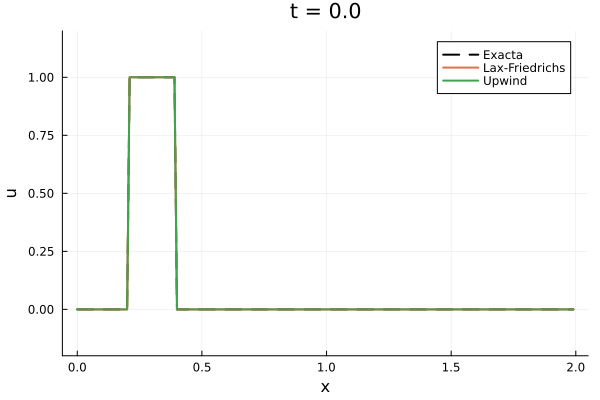

In [8]:
u_lf_t = copy(u0)
u_uw_t = copy(u0)

anim = @animate for n in 0:nsteps
    t = n * dt
    ue = exact(x, a, t, L)

    plot(x, ue, label="Exacta", lw=2, color=:black, linestyle=:dash,
         ylim=(-0.2, 1.2), xlabel="x", ylabel="u",
         title="t = $(round(t, digits=3))")
    plot!(x, u_lf_t, label="Lax-Friedrichs", lw=2)
    plot!(x, u_uw_t, label="Upwind", lw=2)

    if n < nsteps
        global u_lf_t = lax_friedrichs(u_lf_t, a, dx, dt, 1)
        global u_uw_t = upwind(u_uw_t, a, dx, dt, 1)
    end
end

gif(anim, "lax_friedrichs_vs_upwind.gif", fps=15)

Se ve claramente cómo el frente de Lax--Friedrichs se va "achatando" a medida que avanza, mientras que upwind mantiene un perfil más definido (aunque también se difunde, solo que menos). Para comparar con el régimen casi sin difusión, probá cambiar `ν` a `0.99` en la celda de parámetros, volver a correr todo el notebook, y regenerar la animación.